In [12]:
from datascience import *
import numpy as np

import matplotlib.pyplot as plots

%matplotlib inline

In [13]:
def standard_units(x):
    return (x - np.mean(x)) / np.std(x)

In [14]:
def correlation(t, x, y):
    x_su = standard_units(t.column(x))
    y_su = standard_units(t.column(y))
    return np.mean(x_su * y_su)

In [15]:
hybrid = Table.read_table("hybrid.csv")
hybrid.show(3)

vehicle,year,msrp,acceleration,mpg,class
Prius (1st Gen),1997,24509.7,7.46,41.26,Compact
Tino,2000,35355,8.2,54.1,Compact
Prius (2nd Gen),2000,26832.2,7.97,45.23,Compact


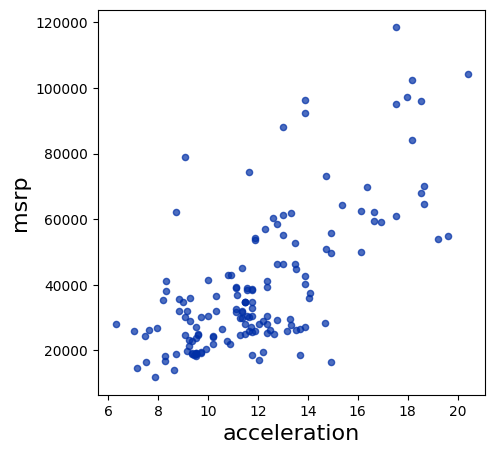

In [16]:
hybrid.scatter("acceleration", "msrp")

In [17]:
correlation(hybrid, "acceleration", "msrp")

0.69557789969139783

In [18]:
sat2014 = Table.read_table("sat2014.csv").sort("State")
sat2014.show(3)

State,Participation Rate,Critical Reading,Math,Writing,Combined
Alabama,6.7,547,538,532,1617
Alaska,54.2,507,503,475,1485
Arizona,36.4,522,525,500,1547


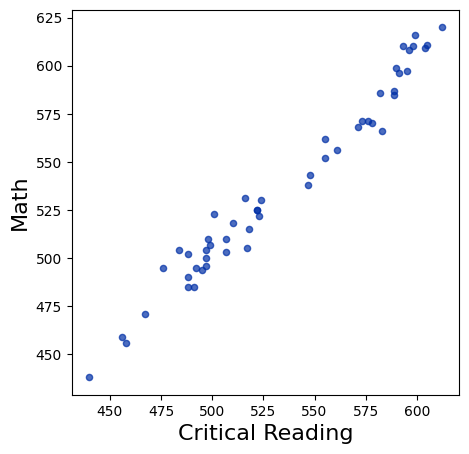

In [19]:
sat2014.scatter("Critical Reading", "Math")

In [20]:
correlation(sat2014, "Critical Reading", "Math")

0.98475584110674341

In [22]:
# Some functions for plotting. You don't have to understand how any
# of the functions in this cell work, since they use things we 
# haven't learned about in Data 8.


def resize_window(lim=3.5):
    plots.xlim(-lim, lim)
    plots.ylim(-lim, lim)
    
def draw_line(slope=0, intercept=0, x=make_array(-4, 4), color='#1e90ff'):
    y = x*slope + intercept
    plots.plot(x, y, color=color, lw=3)
    
def draw_vertical_line(x_position, color='black'):
    x = make_array(x_position, x_position)
    y = make_array(-4, 4)
    plots.plot(x, y, color=color, lw=3)
    
def make_correlated_data(r):
    x = np.random.normal(0, 1, 1000)
    z = np.random.normal(0, 1, 1000)
    y = r*x + (np.sqrt(1-r**2))*z
    return x, y

def r_scatter(r):
    """Generate a scatter plot with a correlation approximately r"""
    plots.figure(figsize=(5,5))
    x, y = make_correlated_data(r)
    plots.scatter(x, y, color='darkblue', s=20)
    plots.xlim(-4, 4)
    plots.ylim(-4, 4)
def r_table(r):
    """
    Generate a table of 1000 data points with a correlation approximately r
    """
    np.random.seed(8)
    x, y = make_correlated_data(r)
    return Table().with_columns('x', x, 'y', y)

In [23]:
example = r_table(0.99)
example.show(5)

x,y
0.0912047,-0.0680119
1.09128,1.04391
-1.94697,-1.88316
-1.38635,-1.34674
-2.29649,-2.14933


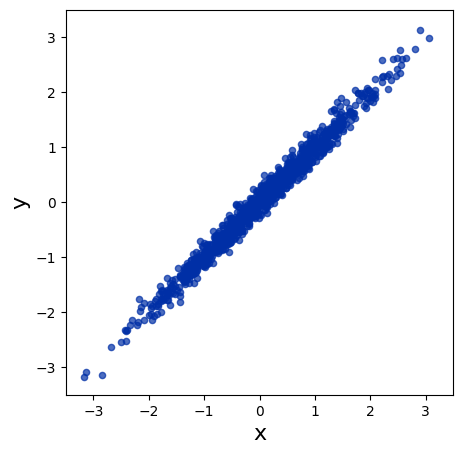

In [26]:
example.scatter("x", "y")
resize_window()

In [27]:
def nn_prediction_example(x_val):
    neighbours = example.where("x", are.between(x_val-0.25, x_val+0.25))
    return np.mean(neighbours.column("y"))

In [28]:
nn_prediction_example(-2.25)

-2.1476337989800527